In [1]:
import os
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import rioxarray as rxr

data_dir = "/storage/dlhogan/precipitation-rodeo/data/"

# Sand Castle 1: Merging SAIL datasets

In [2]:
original_file_dir = "/storage/dlhogan/precipitation-rodeo/data/raw/SAIL"
filename = "SAIL_met_all.nc"

In [ ]:
ds = xr.open_dataset(os.path.join(original_file_dir, filename))

In [ ]:
# save the merged dataset to a new NetCDF file
lat = ds["lat"].values[0]
lon = ds["lon"].values[0]
elev = ds["alt"].values[0]

# Create a GeoDataFrame and name after dataset.attrs['datastream']

gdf = gpd.GeoDataFrame(
    {
        "datastream": [ds.attrs.get("datastream", "unknown")],
        "latitude": [lat],
        "longitude": [lon],
        "elevation": [elev],
    },
    geometry=[Point(lon, lat, elev)],
    crs="EPSG:4326",
)

# Sand Castle 2: Extracting PRISM data for specific basin

In [2]:
def clip_prism(raster_path, shape_path):
    # Prepare output path
    out_path = raster_path.replace("raw", "processed").replace(".nc", "_clipped.nc")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    # Open raster
    with xr.open_dataset(raster_path) as ds:
        # Read shapefile
        shape = gpd.read_file(shape_path)

        # Set CRS for raster
        crs = ds.crs.attrs["crs_wkt"]
        ds = ds.rio.write_crs(crs)

        # Transform shapefile to match raster CRS
        shape = shape.to_crs(ds.rio.crs)

        # Clip raster
        clipped = ds.rio.clip(shape.geometry, shape.crs, drop=True)

        # Rename variable to ppt and set attributes
        clipped = clipped.rename({"Band1": "ppt"})
        clipped["ppt"].attrs["units"] = "mm"
        clipped["ppt"].attrs["long_name"] = "PRISM daily precipitation"

        # Write clipped file
        clipped.to_netcdf(out_path)

    # Delete original only if the clipped file was successfully written
    if os.path.exists(out_path):
        os.remove(raster_path)
        print(f"✅ Original deleted: {raster_path}")

    return

In [3]:
example_path = "/storage/dlhogan/precipitation-rodeo/data/external/PRISM/raw/prism_ppt_us_30s_20201023.nc"
shape_path = "/storage/dlhogan/precipitation-rodeo/data/geographic/East_River_lumped_HRUs_GRUs.shp"

clip_prism(example_path, shape_path)

✅ Original deleted: /storage/dlhogan/precipitation-rodeo/data/external/PRISM/raw/prism_ppt_us_30s_20201023.nc


In [3]:
ds = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/external/PRISM/processed/prism_ppt_us_30s_20201024_clipped.nc")

In [4]:
ds

<xarray.Dataset> Size: 8kB
Dimensions:  (lat: 44, lon: 44)
Coordinates:
  * lat      (lat) float64 352B 38.67 38.68 38.68 38.69 ... 39.01 39.02 39.03
  * lon      (lon) float64 352B -107.1 -107.1 -107.1 ... -106.8 -106.8 -106.8
Data variables:
    crs      int64 8B ...
    ppt      (lat, lon) float32 8kB ...
Attributes:
    Conventions:  CF-1.5
    GDAL:         GDAL 3.4.3, released 2022/04/22
    history:      Tue Oct 14 15:33:15 2025: GDAL CreateCopy( /nfs/pancake/u5/...

# Sand Castle 3: ERA5-Land Data

In [ ]:
import cdsapi
import pandas as pd
import xarray as xr

# Set the time zone shift as a variable so it is easy to change
TIME_ZONE_SHIFT_HOURS = -7  # UTC-7 for MDT

# Calculate the time the TIME-ZONE midnight in UTC
LOCAL_MIDNIGHT_IN_UTC = (0-TIME_ZONE_SHIFT_HOURS) % 24
TIME_STEPS = ['00:00', f"{LOCAL_MIDNIGHT_IN_UTC:02d}:00"]
client = cdsapi.Client() 
dataset = "reanalysis-era5-land"
request = {
    'product_type': ['reanalysis'],
    'variable': ['total_precipitation'],
    'date': '20240101/20240131',
    'time': TIME_STEPS,
    'area': [39.1, -107.1, 38.8, -106.8],  # North, West, South, East
    'grid': [1, 1],
    'data_format': 'netcdf',
}
result_file = client.retrieve(dataset, request).download("/storage/dlhogan/precipitation-rodeo/data/external/ERA5-Land/era5_land_20240101_20240131.zip")

2025-10-14 16:29:41,700 INFO Request ID is c4ec8237-bfd1-41c3-8c56-ed474c6ef812
2025-10-14 16:29:41,913 INFO status has been updated to accepted
2025-10-14 16:29:56,158 INFO status has been updated to successful


6e1e79d8ae6dc38756a3bf3f37402ce1.zip:   0%|          | 0.00/25.2k [00:00<?, ?B/s]

In [28]:
result_file

'/storage/dlhogan/precipitation-rodeo/data/external/ERA5-Land/era5_land_20240101_20240131.zip'

In [30]:
import zipfile
import os

# unzip if needed
if result_file.endswith(".zip"):
    with zipfile.ZipFile(result_file, 'r') as zip_ref:
        zip_ref.extractall(os.path.dirname(result_file))
    # Remove the zip file after extraction
    os.remove(result_file)
    result_file = result_file.replace(".zip", ".nc")
    # rename the file to era5_land_20240101_20240131.nc
    new_file_path = os.path.join(os.path.dirname(result_file), "era5_land_20240101_20240131.nc")
    os.rename(result_file, new_file_path)
    result_file = new_file_path
ds = xr.open_dataset(
    "/storage/dlhogan/precipitation-rodeo/data/external/ERA5-Land/era5_land_20240101_20240131.nc"
)
ds

<xarray.Dataset> Size: 2kB
Dimensions:     (valid_time: 62, latitude: 1, longitude: 1)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 496B 2024-01-01 ... 2024-01-31T07...
  * latitude    (latitude) float64 8B 38.8
  * longitude   (longitude) float64 8B -107.1
    expver      (valid_time) <U4 992B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 248B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-14T23:19 GRIB to CDM+CF via cfgrib-0.9.1...

In [14]:
# Group the data by hour
ds_grouped_by_hour = ds.groupby("valid_time.hour")

# Then create new datasets for the UTC midnight and the local midnight
i_UTC_minight, i_local_midnight = ds_grouped_by_hour.groups
ds_UTC_midnight = ds.isel(valid_time=ds_grouped_by_hour.groups[i_UTC_minight])
ds_local_midnight = ds.isel(valid_time=ds_grouped_by_hour.groups[i_local_midnight])

ds_local_midnight = ds_local_midnight.assign_coords(
    valid_time=ds_UTC_midnight.valid_time + pd.Timedelta(days=1)
)

# Subtract the UTC midnight data from the local midnight data
ds_local_to_utc_midnight = ds_UTC_midnight - ds_local_midnight
# Shift the time back one day
ds_local_to_utc_midnight = ds_local_to_utc_midnight.assign_coords(
    valid_time=ds_local_to_utc_midnight.valid_time - pd.Timedelta(days=1)
)

ds_accum_local = ds_local_midnight + ds_local_to_utc_midnight

shift = int(TIME_ZONE_SHIFT_HOURS < 0)
ds_accum_local = ds_accum_local.assign_coords(
    valid_time=ds_accum_local.valid_time + pd.Timedelta(days=shift)
)

# Sand Castle 4: Testing laser disdrometer output

In [39]:
ds = xr.open_dataset(f"{data_dir}/processed/SPLASH/SPLASH_kp_laser_disdrometer_30min.nc")

# Sand Castle 5: Working on processing AOS met data

In [5]:
import glob
import os
os.chdir("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/")
from utils import process_sail_data
from utils.helper_funcs import convert_to_local_time
import numpy as np
from scipy import stats

files = glob.glob(f"{data_dir}/raw/SAIL/aos_mtcb/*.nc")
example_ds = xr.open_dataset(files[1])

In [6]:
precipitation_sum_vars = [v for v in process_sail_data.SAIL_PRECIPITATION_VARS['cumulative'] if v in example_ds.data_vars]
precipitation_duration_vars = [v for v in process_sail_data.SAIL_PRECIPITATION_VARS['duration'] if v in example_ds.data_vars]
precipitation_rate_vars = [v for v in process_sail_data.SAIL_PRECIPITATION_VARS['rate'] if v in example_ds.data_vars]
relative_humidity_vars = [v for v in process_sail_data.SAIL_HUMIDITY_VARS['mean'] if v in example_ds.data_vars]
wind_spd_vars = [v for v in process_sail_data.SAIL_WIND_VARS['mean'] if v in example_ds.data_vars] + ["u", "v"]
wind_dir_vars = [v for v in process_sail_data.SAIL_WIND_VARS['median'] if v in example_ds.data_vars]
temperature_vars = [v for v in process_sail_data.SAIL_TEMPERATURE_VARS['mean'] if v in example_ds.data_vars]
pressure_vars = [v for v in process_sail_data.SAIL_PRESSURE_VARS['mean'] if v in example_ds.data_vars]

KeyError: 'median'

In [7]:
# calculate u and v from wind speed and direction
def calculate_wind_components(wind_speed, wind_direction):
    """
    Calculate the u and v components of wind from wind speed and direction.

    Parameters:
    wind_speed (float or np.ndarray): Wind speed in m/s.
    wind_direction (float or np.ndarray): Wind direction in degrees from north.

    Returns:
    tuple: A tuple containing the u and v components of the wind.
    """
    # Convert wind direction from degrees to radians
    wind_direction_rad = np.radians(wind_direction)

    # Calculate u and v components
    u = -wind_speed * np.sin(wind_direction_rad)  # East-West component
    v = -wind_speed * np.cos(wind_direction_rad)  # North-South component

    return u.data, v.data
def xr_mode(x, axis=None):
    """Compute the statistical mode for an xarray reduce operation."""
    mode_result = stats.mode(x, nan_policy='omit', axis=axis)
    return xr.DataArray(mode_result.mode)


u, v = calculate_wind_components(example_ds['wind_speed'].values, example_ds['wind_direction'].values)

# Add u and v to the dataset
example_ds['u'] = (('time'), u)
example_ds['v'] = (('time'), v)
example_ds['u'].attrs['units'] = 'm/s'
example_ds['v'].attrs['units'] = 'm/s'
example_ds['u'].attrs['long_name'] = 'East-West wind component'
example_ds['v'].attrs['long_name'] = 'North-South wind component'

example_ds = convert_to_local_time(example_ds, local_tz='America/Denver')

In [71]:
precipitation_sum_da      = example_ds[precipitation_sum_vars].resample(time='30min').sum()
precipitation_duration_da = example_ds[precipitation_duration_vars].resample(time='30min').sum()
precipitation_rate_da     = example_ds[precipitation_rate_vars].resample(time='30min').mean()
relative_humidity_da      = example_ds[relative_humidity_vars].resample(time='30min').mean()
wind_spd_da               = example_ds[wind_spd_vars].resample(time='30min').mean()
wind_dir_da               = example_ds[wind_dir_vars].resample(time='30min').reduce(xr_mode)
temperature_da            = example_ds[temperature_vars].resample(time='30min').mean()
pressure_da               = example_ds[pressure_vars].resample(time='30min').mean()

In [73]:
# assign units to the new data arrays
for var in precipitation_sum_vars:
    precipitation_sum_da[var].attrs['units'] = 'mm'
for var in precipitation_duration_vars:
    # convert from seconds to minutes if needed
    if precipitation_duration_da[var].attrs['units'] == 's':
        precipitation_duration_da[var] = precipitation_duration_da[var] / 60
        precipitation_duration_da[var].attrs['units'] = 'min'
for var in precipitation_rate_vars:
    precipitation_rate_da[var].attrs['units'] = 'mm/hr'
for var in relative_humidity_vars:
    relative_humidity_da[var].attrs['units'] = '%'
for var in wind_spd_vars:
    wind_spd_da[var].attrs['units'] = 'm/s'
for var in wind_dir_vars:
    wind_dir_da[var].attrs['units'] = 'deg'
for var in temperature_vars:
    temperature_da[var].attrs['units'] = 'degC'
for var in pressure_vars:
    pressure_da[var].attrs['units'] = 'hPa'

In [74]:
ds_merged = xr.merge([
        precipitation_sum_da,
        precipitation_duration_da,
        precipitation_rate_da,
        relative_humidity_da,
        wind_spd_da,
        wind_dir_da,
        temperature_da,
        pressure_da
    ])

# Sand Castle 6: Laser disdrometer processing for SAIL

In [2]:
import glob
import os
import sys, os
project_root = "/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo"
os.chdir(project_root)
from utils import process_sail_data
from utils.helper_funcs import convert_to_local_time
import xarray as xr
import time
import numpy as np
from scipy import stats
import pandas as pd

# Assign data directory and get files
SITE_NAME = "gothic"
data_dir = "/storage/dlhogan/precipitation-rodeo/data/"
files = glob.glob(f"{data_dir}raw/SAIL/laser_disdrometer_{SITE_NAME}/*.nc")

In [ ]:
ds = xr.open_dataset(files[0])

# Number density of particles
N_D = ds['number_density_drops']
# Fall velocity of particles summed over raw_fall_velocity
V_D = ds['fall_velocity_calculated']
# Class size width
class_size_width = ds['class_size_width']

Z_hh = ds['equivalent_radar_reflectivity_ott']
K_ice = 0.93  #

<xarray.Dataset> Size: 63MB
Dimensions:                               (time: 7200, particle_size: 32,
                                           raw_fall_velocity: 32)
Coordinates:
  * time                                  (time) datetime64[ns] 58kB 2021-09-...
  * particle_size                         (particle_size) float32 128B 0.062 ...
  * raw_fall_velocity                     (raw_fall_velocity) float32 128B 0....
Data variables: (12/42)
    base_time                             (time) datetime64[ns] 58kB ...
    time_offset                           (time) datetime64[ns] 58kB ...
    precip_rate                           (time) float32 29kB ...
    qc_precip_rate                        (time) int32 29kB ...
    weather_code                          (time) float32 29kB ...
    qc_weather_code                       (time) int32 29kB ...
    ...                                    ...
    moment4                               (time) float32 29kB ...
    moment5                               (time) float32 29kB ...
    moment6                               (time) float32 29kB ...
    lat                                   (time) float32 29kB ...
    lon                                   (time) float32 29kB ...
    alt                                   (time) float32 29kB ...
Attributes: (12/15)
    command_line:                ld_ingest -s guc -f M1
    process_version:             ingest-ld-1.3-0.el7
    dod_version:                 ld-b1-2.0
    Conventions:                 ARM-1.2
    data_level:                  b1
    platform_id:                 ld
    ...                          ...
    facility_id:                 M1
    sampling_interval:           1 minute
    effective_measurement_area:  0.54 m^2
    doi:                         10.5439/1560674
    datastream:                  gucldM1.b1
    history:                     created by user dsmgr on machine flint at 20...

In [ ]:
parsivel_correction_dict = { 
    'holroyd1971': [0.17, -1],
    'brandes2007': [0.178, -0.922],
    'heymsfield2004': [0.104, -0.95]
}

def correct_SAIL_parsivel_for_snow(ds, method='holroyd1971'):
    """
    Correct snowfall rate using a method discussed in Boudala et al. 2014
    """
    a = parsivel_correction_dict[method][0]
    b = parsivel_correction_dict[method][1]
    # Number density of particles
    N_D = ds['number_density_drops']
    # Fall velocity of particles summed over raw_fall_velocity
    V_D = ds['fall_velocity_calculated']
    # Class size width
    class_size_width = ds['class_size_width']

    # Apply the condition to include particle sizes from 2 to 31
    particle_size_indices = range(2, 32)
    raw_fall_velocity_indices = range(2, 32)

    # Select the relevant slices using isel
    N_D_masked = N_D.isel(particle_size=particle_size_indices)
    class_size_width_masked = class_size_width.isel(particle_size=particle_size_indices)
    V_D_masked = V_D.isel(raw_fall_velocity=raw_fall_velocity_indices)

    # Calculate the snowfall rate using vectorized operations
    result = (N_D_masked * V_D_masked * class_size_width_masked ** (3 + b)).sum(dim='particle_size').sum(dim='raw_fall_velocity')

    # Calculate the final result
    final_result = (6 * a * np.pi * 10e-4 * result)/60
    # filter to only include times with snowfall
    final_result = final_result.where(ds['weather_code'].isin([70,71,72,73,74,75,76,77,78,79,85,86,87]), ds['precip_rate'])
    return final_result

def apply_chang22_correction(ds):
    """
    Apply the Chang et al. 2022 correction to the SAIL laser disdrometer data.
    This correction adjusts the precipitation rate based on temperature.
    """
    N_D = ds['number_density_drops']
    V_D = ds['fall_velocity_calculated']
    class_size_width = ds['class_size_width']   
    
    return

def xr_mode(x, axis=None):
    """Compute the statistical mode for an xarray reduce operation."""
    mode_result = stats.mode(x, nan_policy='omit', axis=axis)
    return xr.DataArray(mode_result.mode)

1. read data file (1-minute resolution)
2. filter to only variables we want to keep
3. filter out any bad data
4. calculate correction for snow using all methods (save these as individual arrays)
5. create accumulated variable
6. convert time to local time
7. resample to desired length using appropriate function for each variable
8. 

In [ ]:
ds = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/SAIL/laser_disdrometer_gothic_processed_30min.nc")

<xarray.Dataset> Size: 4MB
Dimensions:                            (time: 480, particle_size: 32,
                                        raw_fall_velocity: 32)
Coordinates:
  * time                               (time) datetime64[ns] 4kB 2021-08-31T1...
  * particle_size                      (particle_size) float32 128B 0.062 ......
  * raw_fall_velocity                  (raw_fall_velocity) float32 128B 0.05 ...
Data variables: (12/21)
    precip_accum_unadjusted           (time) float32 2kB ...
    precip_accum_holyroyd              (time) float32 2kB ...
    precip_accum_brandes               (time) float32 2kB ...
    precip_accum_heymsfield            (time) float32 2kB ...
    number_detected_particles          (time) float64 4kB ...
    precip_rate                        (time) float64 4kB ...
    ...                                 ...
    weather_code                       (time) float32 2kB ...
    mor_visibility                     (time) float64 4kB ...
    median_volume_diameter             (time) float64 4kB ...
    lon                                (time) float32 2kB ...
    lat                                (time) float32 2kB ...
    alt                                (time) float32 2kB ...
Attributes:
    units:      mm
    long_name:  Accumulated precipitation unadjusted

# Sand Castle 7: MET station processing for SAIL

In [1]:
import glob
import os
import sys, os
project_root = "/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo"
if project_root not in sys.path:
    sys.path.append(project_root)
from utils import process_sail_data
from utils.helper_funcs import convert_to_local_time, qc_sail_met, calculate_wind_components
import xarray as xr
import time
import numpy as np
from scipy import stats
import pandas as pd

# Assign data directory and get files
data_dir = "/storage/dlhogan/precipitation-rodeo/data/"
files = glob.glob(f"{data_dir}raw/SAIL/met/*.nc")

vars_to_keep = [
    'atmos_pressure',
    'temp_mean',
    'rh_mean',
    'vapor_pressure_mean',
    'wspd_vec_mean',
    'wdir_vec_mean',
    'pwd_err_code',
    'pwd_mean_vis_1min',
    'pwd_precip_rate_mean_1min',
    'pwd_cumul_rain',
    'pwd_cumul_snow',
    'org_precip_rate_mean',
    'tbrg_precip_total',
    'tbrg_precip_total_corr',
    'lat',
    'lon',
    'alt',
]

In [2]:
ds = process_sail_data.initial_sail_processing(files[7], vars_to_keep=vars_to_keep)

In [10]:
# create accumulated variables
org_precip_accum= ds["org_precip_rate_mean"]/60
org_precip_accum.name = "org_precip_accum"
org_precip_accum.attrs["units"] = "mm"
org_precip_accum.attrs["long_name"] = "Original Precipitation Accumulation"

# calculate wind components
# Calculate u and v components if both wind speed and direction are present
if 'wspd_vec_mean' in ds and 'wdir_vec_mean' in ds:
    u, v = calculate_wind_components(ds['wspd_vec_mean'], ds['wdir_vec_mean'])
    ds['u'] = (('time',), u)
    ds['v'] = (('time',), v)
    ds['u'].attrs['units'] = 'm/s'
    ds['v'].attrs['units'] = 'm/s'
    ds['u'].attrs['long_name'] = 'East-West wind component'
    ds['v'].attrs['long_name'] = 'North-South wind component'

In [11]:
# resample to desired length
# accumulated variables: sum
org_precip_accum_da = org_precip_accum.resample(time='30min').sum()
pwd_cumul_rain_da = ds['pwd_cumul_rain'].resample(time='30min').sum()
pwd_cumul_snow_da = ds['pwd_cumul_snow'].resample(time='30min').sum()
tbrg_precip_total_da = ds['tbrg_precip_total'].resample(time='30min').sum()
tbrg_precip_total_corr_da = ds['tbrg_precip_total_corr'].resample(time='30min').sum()

# mean variables: mean
atmos_pressure_da = ds['atmos_pressure'].resample(time='30min').mean()
temp_mean_da = ds['temp_mean'].resample(time='30min').mean()
rh_mean_da = ds['rh_mean'].resample(time='30min').mean()
vapor_pressure_mean_da = ds['vapor_pressure_mean'].resample(time='30min').mean()
wspd_vec_mean_da = ds['wspd_vec_mean'].resample(time='30min').mean()
u_mean_da = ds['u'].resample(time='30min').mean()
v_mean_da = ds['v'].resample(time='30min').mean()
pwd_precip_rate_mean_da = ds['pwd_precip_rate_mean_1min'].resample(time='30min').mean()
org_precip_rate_mean_da = ds['org_precip_rate_mean'].resample(time='30min').mean()

# mode variables: mode
# silence small sample warning
import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    wdir_vec_mean_da = ((10 * np.round(ds['wdir_vec_mean'] / 10)).astype(int)).resample(time='30min').reduce(xr_mode)
    pwd_err_code_da = (ds['pwd_err_code'].fillna(0)).resample(time='30min').reduce(xr_mode)
    pwd_mean_vis_1min_da = ds['pwd_mean_vis_1min'].resample(time='30min').reduce(xr_mode)

# first value for lat, lon, alt
lat_da = ds['lat'].resample(time='30min').first()
lon_da = ds['lon'].resample(time='30min').first()
alt_da = ds['alt'].resample(time='30min').first()

# merge all data arrays
ds_merged = xr.merge([
    org_precip_accum_da,
    pwd_cumul_rain_da,
    pwd_cumul_snow_da,
    tbrg_precip_total_da,
    tbrg_precip_total_corr_da,
    atmos_pressure_da,
    temp_mean_da,
    rh_mean_da,
    vapor_pressure_mean_da,
    wspd_vec_mean_da,
    u_mean_da,
    v_mean_da,
    pwd_precip_rate_mean_da,
    org_precip_rate_mean_da,
    wdir_vec_mean_da,
    pwd_err_code_da,
    pwd_mean_vis_1min_da,
    lat_da,
    lon_da,
    alt_da
])


# Sandbox 8: Process SAIL pluviometer data

In [5]:
import glob
import os
import sys, os
project_root = "/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo"
if project_root not in sys.path:
    sys.path.append(project_root)
from utils import process_sail_data
from utils.helper_funcs import convert_to_local_time
import xarray as xr
import time
import numpy as np
from scipy import stats
import pandas as pd

# Assign data directory and get files
data_dir = "/storage/dlhogan/precipitation-rodeo/data/"
files = glob.glob(f"{data_dir}raw/SAIL/pluvio/*.nc")

In [2]:
vars_to_keep = [
    'intensity_rt',
    'accum_rtnrt',
    'accum_nrt',
    'accum_total_nrt',
    'maintenance_flag',
    'pluvio_status',
    'heater_status',
    'reset_flag',
    'intensity_rtnrt',
    'lat',
    'lon',
    'alt',
]

In [200]:
ds = process_sail_data.initial_sail_processing(files[7], vars_to_keep=vars_to_keep)

In [193]:
# resample variables to desired length
resample_length = "30min"
# accumulated variables: sum
accum_rtnrt_da = ds['accum_rtnrt'].resample(time=resample_length).sum()
accum_nrt_da = ds['accum_nrt'].resample(time=resample_length).sum()
accum_total_nrt_da = ds['accum_total_nrt'].resample(time=resample_length).sum()
# rate variables: mean
intensity_rt_da = ds['intensity_rt'].resample(time=resample_length).mean()
intensity_rtnrt_da = ds['intensity_rtnrt'].resample(time=resample_length).mean()
# first value for lat, lon, alt
lat_da = ds['lat'].resample(time=resample_length).first()
lon_da = ds['lon'].resample(time=resample_length).first()
alt_da = ds['alt'].resample(time=resample_length).first()

ds_merged = xr.merge([
    accum_rtnrt_da,
    accum_nrt_da,
    accum_total_nrt_da,
    intensity_rt_da,
    intensity_rtnrt_da,
    lat_da,
    lon_da,
    alt_da
])


In [3]:
ds = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/SAIL/pluvio_30min.nc")

# Sandbox 9: Process SQUIRE data

Goal is to get the SQUIRE grid point from the radar over Gothic and Kettle Ponds

In [11]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
import sys, os
project_root = "/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo"
if project_root not in sys.path:
    sys.path.append(project_root)
from utils.helper_funcs import convert_to_local_time, get_point_info
import time

def process_squire_data(files, resample_interval='30min', gothic_point_info=None, kettle_ponds_point_info=None):
    ds_list_gothic = []
    ds_list_kettle_ponds = []
    for i, file in enumerate(files[0:3]):
        print(f"Processing file {i+1}/{len(files)}: {file}")
        start = time.time()
        ds = xr.open_dataset(file)

        # convert the ds to use lat and lon as the coordinates, replacing x and y
        ds['x'] = ds['x'].assign_coords({'x': ds['lon'].values})
        ds['y'] = ds['y'].assign_coords({'y': ds['lat'].values})
        ds = ds.swap_dims({'x': 'lon', 'y': 'lat'})

        # exclude dBZ and corrected_reflectivity variables
        ds = ds.drop_vars(['DBZ', 'corrected_reflectivity', 'lowest_height'])
        # convert to local time
        ds = convert_to_local_time(ds, local_tz='America/Denver')

        # grab the nearest point to gothic
        ds_gothic = ds.sel(lon=gothic_point_info['longitude'].values
                            , lat=gothic_point_info['latitude'].values, method='nearest').squeeze()
        ds_gothic = ds_gothic.expand_dims(site=['gothic'])
        ds_kettle_ponds = ds.sel(lon=kettle_ponds_point_info['longitude'].values
                            , lat=kettle_ponds_point_info['latitude'].values, method='nearest').squeeze()
        ds_kettle_ponds = ds_kettle_ponds.expand_dims(site=['kettle_ponds'])

        # resample to resample interval
        ds_gothic_resampled = ds_gothic.resample(time=resample_interval).mean().squeeze()
        ds_kettle_ponds_resampled = ds_kettle_ponds.resample(time=resample_interval).mean().squeeze()

        # caluclate resample interval total by converting from mm/hour to mm/30min
        ds_gothic_resampled_total = ds_gothic_resampled * 0.5
        ds_kettle_ponds_resampled_total = ds_kettle_ponds_resampled * 0.5

        # rename these variables to indicate total
        for var in ds_gothic_resampled.data_vars:
            ds_gothic_resampled_total = ds_gothic_resampled_total.rename({var: var + '_total'})
        for var in ds_kettle_ponds_resampled.data_vars:
            ds_kettle_ponds_resampled_total = ds_kettle_ponds_resampled_total.rename({var: var + '_total'})

        # add unit and longname attributes for total variables
        for var in ds_gothic_resampled_total.data_vars:
            ds_gothic_resampled_total[var].attrs['units'] = 'mm'
            ds_kettle_ponds_resampled_total[var].attrs['units'] = 'mm'
            ds_gothic_resampled_total[var].attrs['long_name'] = ds_gothic_resampled[var.replace('_total', '')].attrs.get('long_name', '') + ' Total'
            ds_kettle_ponds_resampled_total[var].attrs['long_name'] = ds_kettle_ponds_resampled[var.replace('_total', '')].attrs.get('long_name', '') + ' Total'
            
        # add the total to the original dataset
        ds_gothic_resampled = ds_gothic_resampled.merge(ds_gothic_resampled_total, join='left')
        ds_kettle_ponds_resampled = ds_kettle_ponds_resampled.merge(ds_kettle_ponds_resampled_total, join='left')

        # add attributes from original dataset
        for var in ds.data_vars:
            ds_gothic_resampled[var].attrs = ds[var].attrs
            ds_kettle_ponds_resampled[var].attrs = ds[var].attrs

        # add lat, lon, elev attributes
        ds_gothic_resampled = ds_gothic_resampled.assign_attrs({
            'latitude': gothic_point_info['latitude'].astype('float32').values,
            'longitude': gothic_point_info['longitude'].astype('float32').values,
            'elevation': gothic_point_info['elevation'].astype('float32').values,
            'time_zone': 'America/Denver',  
        })
        ds_kettle_ponds_resampled = ds_kettle_ponds_resampled.assign_attrs({
            'latitude': kettle_ponds_point_info['latitude'].astype('float32').values,
            'longitude': kettle_ponds_point_info['longitude'].astype('float32').values,
            'elevation': kettle_ponds_point_info['elevation'].astype('float32').values,
            'time_zone': 'America/Denver',
        })

        # remove timezone info from time coordinate
        ds_gothic_resampled['time'] = pd.to_datetime(ds_gothic_resampled['time'].values).tz_localize(None)
        ds_kettle_ponds_resampled['time'] = pd.to_datetime(ds_kettle_ponds_resampled['time'].values).tz_localize(None)

        ds_list_gothic.append(ds_gothic_resampled)
        ds_list_kettle_ponds.append(ds_kettle_ponds_resampled)

        end = time.time()
        print(f"Finished processing file {file} in {end - start:.2f} seconds.")
    combined_ds_gothic = xr.concat(ds_list_gothic, dim='time')
    combined_ds_gothic = combined_ds_gothic.sortby('time')
    combined_ds_kettle_ponds = xr.concat(ds_list_kettle_ponds, dim='time')
    combined_ds_kettle_ponds = combined_ds_kettle_ponds.sortby('time')

    # concatenate along site dimension
    combined_ds = xr.concat([combined_ds_gothic, combined_ds_kettle_ponds], dim='site')
    return combined_ds

data_dir = "/storage/dlhogan/precipitation-rodeo/data/"
# check if SQUIRE files are present
if not os.path.exists(f"{data_dir}raw/SAIL/squire_radar/"):
    print("SQUIRE data directory not found. Download the data before proceeding.")
try:
    files = glob.glob(f"{data_dir}raw/SAIL/squire_radar/gucxprecipradarsquireS2.c1*.nc")
except Exception as e:
    print(f"Error finding SQUIRE files: {e}")

RESAMPLE_INTERVAL = '30min'
# get the lon and lat values for gothic and kettle ponds
try:
    example_gothic_ds = xr.open_dataset(f"{data_dir}processed/SAIL/met_30min.nc")
    gothic_point_info = get_point_info(example_gothic_ds)
    print('Got Gothic locations!')
except Exception as e:
    print(f"Error opening example Gothic example dataset: {e}. Make sure the file exists.")
try:
    example_kp_ds = xr.open_dataset(f"{data_dir}processed/SPLASH/asfs30_30min.nc")
    kettle_ponds_point_info = get_point_info(example_kp_ds)
    print('Got Kettle Ponds locations!')
except Exception as e:
    print(f"Error opening example Kettle Ponds example dataset: {e}. Make sure the file exists.")

combined_ds = process_squire_data(
    files, resample_interval=RESAMPLE_INTERVAL,
    gothic_point_info=gothic_point_info,
    kettle_ponds_point_info=kettle_ponds_point_info
)

Got Gothic locations!
Got Kettle Ponds locations!
Processing file 1/228: /storage/dlhogan/precipitation-rodeo/data/raw/SAIL/squire_radar/gucxprecipradarsquireS2.c1.20211201.000000.nc
Finished processing file /storage/dlhogan/precipitation-rodeo/data/raw/SAIL/squire_radar/gucxprecipradarsquireS2.c1.20211201.000000.nc in 0.25 seconds.
Processing file 2/228: /storage/dlhogan/precipitation-rodeo/data/raw/SAIL/squire_radar/gucxprecipradarsquireS2.c1.20211202.000000.nc
Finished processing file /storage/dlhogan/precipitation-rodeo/data/raw/SAIL/squire_radar/gucxprecipradarsquireS2.c1.20211202.000000.nc in 0.26 seconds.
Processing file 3/228: /storage/dlhogan/precipitation-rodeo/data/raw/SAIL/squire_radar/gucxprecipradarsquireS2.c1.20211203.000000.nc
Finished processing file /storage/dlhogan/precipitation-rodeo/data/raw/SAIL/squire_radar/gucxprecipradarsquireS2.c1.20211203.000000.nc in 0.20 seconds.


In [3]:
import xarray as xr
xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/SAIL/squire_30min.nc")

<xarray.Dataset> Size: 3MB
Dimensions:                    (site: 2, time: 10704)
Coordinates:
  * site                       (site) <U12 96B 'gothic' 'kettle_ponds'
    x                          (site) float64 16B ...
    y                          (site) float64 16B ...
    lon                        (site, time) float64 171kB ...
    lat                        (site, time) float64 171kB ...
  * time                       (time) datetime64[ns] 86kB 2021-12-01 ... 2023...
Data variables: (12/14)
    rain_rate_A                (site, time) float64 171kB ...
    snow_rate_ws88diw          (site, time) float64 171kB ...
    snow_rate_m2009_1          (site, time) float64 171kB ...
    snow_rate_m2009_2          (site, time) float64 171kB ...
    snow_rate_ws2012           (site, time) float64 171kB ...
    squire_missing_flag        (site, time) float64 171kB ...
    ...                         ...
    snow_rate_ws88diw_total    (site, time) float64 171kB ...
    snow_rate_m2009_1_total    (site, time) float64 171kB ...
    snow_rate_m2009_2_total    (site, time) float64 171kB ...
    snow_rate_ws2012_total     (site, time) float64 171kB ...
    squire_missing_flag_total  (site, time) float64 171kB ...
    squire_bad_flag_total      (site, time) float64 171kB ...
Attributes: (12/27)
    command_line:          
    Conventions:           ARM-1.3 CF/Radial instrument_parameters
    process_version:       
    dod_version:           
    site_id:               
    platform_id:           
    ...                    ...
    fields:                DBZ, corrected_reflectivity, time, lowest_height, ...
    history:               
    latitude:              38.956158
    longitude:             -106.987854
    elevation:             2886.0
    time_zone:             America/Denver

# Sandbox 10: Process SOS variables

In [209]:
import glob
os.chdir("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/")
import utils.helper_funcs as hf
import numpy as np
storage_dir = "/storage/dlhogan/precipitation-rodeo/data/"
ds = xr.open_dataset(f"{storage_dir}processed/SOS/sos_ds_all_storage.nc")

In [210]:
# change sites array to be ['d', 'ue', 'uw', 'c']
sites = ['d', 'ue', 'uw', 'c']

wind_vars = hf.WIND_VARIABLES
wv_vars = hf.WATER_VAPOR_VARIABLES
temp_vars = hf.TEMPERATURE_VARIABLES
press_vars = hf.PRESSURE_VARIABLES
swe_vars = hf.SWE_VARIABLES
rad_vars = hf.RADIATION_VARIABLES

def fast_mode_rounded(x):
    arr = x.to_numpy()
    arr = arr[~np.isnan(arr)]  # drop NaNs fast
    if arr.size == 0:
        return np.nan
    rounded = (10 * np.round(arr / 10)).astype(int)
    vals, counts = np.unique(rounded, return_counts=True)
    return vals[np.argmax(counts)]

vars_to_keep = wind_vars + wv_vars + temp_vars + press_vars + swe_vars

# only variables at site _c
vars_to_keep = [var for var in vars_to_keep if var.endswith('_c')]

# only keep 2m, 3m, and 10m variables
vars_to_keep = [var for var in vars_to_keep if any(f"_{h}" in var for h in ['2m', '3m', '10m', 'p1', 'p2', 'p3', 'p4'])]

# remove vertical wind speed w_
vars_to_keep = [var for var in vars_to_keep if not var.startswith('w_')] + rad_vars

sub_ds = ds[vars_to_keep]
ds.close()

In [211]:
# for SWE_ variables, bfill NaN values
for var in swe_vars:
    # backward fill values
    sub_ds[var] = sub_ds[var].bfill(dim='time')
    # remove any values with large absolute differences between time steps
    swe_diff = sub_ds[var].diff(dim='time')
    large_diff_mask = np.abs(swe_diff) > 30  # threshold of 30 mm
    # set the value after the large diff to NaN
    indices_to_nan = large_diff_mask.where(large_diff_mask, drop=True).time
    sub_ds[var] = sub_ds[var].where(~sub_ds['time'].isin(indices_to_nan), np.nan)
    # bfill again
    sub_ds[var] = sub_ds[var].bfill(dim='time')
    # create a new variable called var + '_max_accum_swe'
    sub_ds[var + '_max_accum'] = (('time',), np.maximum.accumulate(sub_ds[var].values))
    sub_ds[var + '_max_accum'].attrs['units'] = sub_ds[var].attrs['units']
    sub_ds[var + '_max_accum'].attrs['long_name'] = f"Accumulated {sub_ds[var].attrs.get('long_name', var)}"

In [212]:
# convert to local time
sub_ds = hf.convert_to_local_time(sub_ds, local_tz='America/Denver')

In [ ]:
# resample to 30min
df = sub_ds.to_dataframe()
df = df.resample('30min').agg(
    {
        'SWE_p1_c': 'mean', 'SWE_p2_c': 'mean', 'SWE_p3_c': 'mean', 'SWE_p4_c': 'mean',
        'SWE_p1_c_max_accum': 'mean', 'SWE_p2_c_max_accum': 'mean', 'SWE_p3_c_max_accum': 'mean', 'SWE_p4_c_max_accum': 'mean',
        'spd_2m_c': 'mean', 'dir_2m_c': fast_mode_rounded, 'u_2m_c': 'mean', 'v_2m_c': 'mean',
        'spd_3m_c': 'mean', 'dir_3m_c': fast_mode_rounded, 'u_3m_c': 'mean', 'v_3m_c': 'mean',
        'spd_10m_c': 'mean', 'dir_10m_c': fast_mode_rounded, 'u_10m_c': 'mean', 'v_10m_c': 'mean',
        'h2o_2m_c': 'mean', 'h2o_3m_c': 'mean', 'h2o_10m_c': 'mean',
        'T_2m_c': 'mean', 'T_3m_c': 'mean', 'T_10m_c': 'mean',
        'RH_2m_c': 'mean', 'RH_3m_c': 'mean', 'RH_10m_c': 'mean',
        'P_10m_c': 'mean',
        'Rpile_out_9m_d': 'mean', 'Rpile_in_9m_d': 'mean', 'Rsw_in_9m_d': 'mean', 'Rsw_out_9m_d': 'mean',
    }
)

sub_ds_30min = df.to_xarray()

# add attributes back
for var in sub_ds_30min.data_vars:
    sub_ds_30min[var].attrs = sub_ds[var].attrs

# add global attributes
sub_ds_30min.attrs = sub_ds.attrs


<xarray.Dataset> Size: 2MB
Dimensions:             (time: 9696)
Coordinates:
  * time                (time) datetime64[ns, America/Denver] 78kB 2022-11-29...
Data variables: (12/34)
    SWE_p1_c            (time) float32 39kB 27.96 28.05 28.14 ... 0.0 0.0 0.0
    SWE_p2_c            (time) float32 39kB 21.25 21.56 21.57 ... 0.0 0.0 0.0
    SWE_p3_c            (time) float32 39kB 35.05 35.28 35.3 ... 0.0 0.0 0.0
    SWE_p4_c            (time) float32 39kB 31.32 31.44 31.71 ... 0.0 0.0 0.0
    SWE_p1_c_max_accum  (time) float32 39kB 28.22 28.3 28.31 ... 683.0 683.0
    SWE_p2_c_max_accum  (time) float32 39kB 21.29 21.62 21.79 ... 436.6 436.6
    ...                  ...
    RH_10m_c            (time) float32 39kB 63.87 48.18 48.41 ... 16.38 16.85
    P_10m_c             (time) float32 39kB 713.2 713.4 714.0 ... 720.9 720.9
    Rpile_out_9m_d      (time) float32 39kB -21.36 -31.66 -34.89 ... 7.862 nan
    Rpile_in_9m_d       (time) float32 39kB -74.59 -106.5 -104.7 ... -159.4 nan
    Rsw_in_9m_d         (time) float32 39kB -4.158 -4.515 -4.378 ... 666.0 nan
    Rsw_out_9m_d        (time) float32 39kB -0.6018 -1.114 -1.235 ... 131.7 nan
Attributes:
    project:                   SOS
    history:                   Created: 2024-03-04 08:06:41 +0000\n
    NIDAS_version:             v1.2.3
    calibration_file_path:     /h/eol/isfs/isfs/projects/SOS/ISFS/cal_files/$...
    project_config:            /h/eol/isfs/isfs/projects/SOS/ISFS/config/sos....
    wind3d_horiz_coordinates:  geographic
    file_length_seconds:       86400
    wind3d_horiz_rotation:     1
    wind3d_tilt_correction:    1

In [220]:
ds = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/SOS/sos_ds_30min.nc")
ds

<xarray.Dataset> Size: 2MB
Dimensions:             (time: 9696)
Coordinates:
  * time                (time) datetime64[ns] 78kB 2022-11-30 ... 2023-06-19T...
Data variables: (12/34)
    SWE_p1_c            (time) float32 39kB ...
    SWE_p2_c            (time) float32 39kB ...
    SWE_p3_c            (time) float32 39kB ...
    SWE_p4_c            (time) float32 39kB ...
    SWE_p1_c_max_accum  (time) float32 39kB ...
    SWE_p2_c_max_accum  (time) float32 39kB ...
    ...                  ...
    RH_10m_c            (time) float32 39kB ...
    P_10m_c             (time) float32 39kB ...
    Rpile_out_9m_d      (time) float32 39kB ...
    Rpile_in_9m_d       (time) float32 39kB ...
    Rsw_in_9m_d         (time) float32 39kB ...
    Rsw_out_9m_d        (time) float32 39kB ...
Attributes:
    project:                   SOS
    history:                   Created: 2024-03-04 08:06:41 +0000\n
    NIDAS_version:             v1.2.3
    calibration_file_path:     /h/eol/isfs/isfs/projects/SOS/ISFS/cal_files/$...
    project_config:            /h/eol/isfs/isfs/projects/SOS/ISFS/config/sos....
    wind3d_horiz_coordinates:  geographic
    file_length_seconds:       86400
    wind3d_horiz_rotation:     1
    wind3d_tilt_correction:    1

# Sandbox 11:  Process SPLASH ASFS data from KP

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
import os 
os.chdir("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/")
import utils.helper_funcs as hf

# check if ASFS-30 files are present
if not os.path.exists(f"{data_dir}raw/SPLASH/ASFS-30_Level2_SPLASH2021-2023/"):
    print("ASFS-30 data directory not found. Download the data before proceeding.")
try:
    files = glob.glob(f"{data_dir}raw/SPLASH/ASFS-30_Level2_SPLASH2021-2023/sledseb.asfs30.level2.0.10min*.nc")
except Exception as e:
    print(f"Error finding ASFS-30 files: {e}")

In [ ]:
ds = xr.open_dataset(files[0])

vars_to_keep = [
    'lat',
    'lon',
    'altitude',
    'snow_depth',
    'atmos_pressure',
    'temp',
    'rh',
    'vapor_pressure',
    'rhi',
    'wspd_u_mean',
    'wspd_v_mean',
    'down_long_hemisp',
    'down_short_hemisp',
    'up_long_hemisp',
    'up_short_hemisp',
]
qc_vars = [v + '_qc' for v in vars_to_keep if v + '_qc' in ds.data_vars]

In [15]:
sub_ds = ds[vars_to_keep + qc_vars]

# qc relevant data when qc vars are bad
for var in vars_to_keep:
    qc_var = var + '_qc'
    if qc_var in sub_ds.data_vars:
        sub_ds[var] = sub_ds[var].where(sub_ds[qc_var] == 0, other=np.nan)

# drop qc vars
sub_ds = sub_ds.drop_vars(qc_vars)

# convert to local time
sub_ds = hf.convert_to_local_time(sub_ds, local_tz='America/Denver')

# resample to 30min
sub_ds_30min = sub_ds.resample(time='30min').mean()


In [ ]:
ds = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/SPLASH/asfs30_30min.nc")

<xarray.Dataset> Size: 4MB
Dimensions:            (time: 31008)
Coordinates:
  * time               (time) datetime64[ns] 248kB 2021-09-28 ... 2023-07-19T...
Data variables: (12/15)
    lat                (time) float64 248kB ...
    lon                (time) float64 248kB ...
    altitude           (time) float64 248kB ...
    snow_depth         (time) float64 248kB ...
    atmos_pressure     (time) float64 248kB ...
    temp               (time) float64 248kB ...
    ...                 ...
    wspd_u_mean        (time) float64 248kB ...
    wspd_v_mean        (time) float64 248kB ...
    down_long_hemisp   (time) float64 248kB ...
    down_short_hemisp  (time) float64 248kB ...
    up_long_hemisp     (time) float64 248kB ...
    up_short_hemisp    (time) float64 248kB ...
Attributes: (12/16)
    date_created:     Fri Dec  8 10:57:03 2023
    title:            Study of Precipitation, the Lower Atmosphere and Surfac...
    institution:      NOAA Physical Sciences Laboratory (PSL) and CIRES/Unive...
    file_creator:     Michael R. Gallagher; Christopher J. Cox
    creator_email:    michael.r.gallagher@noaa.gov; christopher.j.cox@noaa.gov
    Funding:          NOAA Physical Sciences Laboratory (PSL)
    ...               ...
    conventions:      cf convention variable naming as attribute whenever pos...
    history:          processed data based on level 1 ingest files
    version:          1.0, 9/18/2023
    quality_control:  Quality control in place for the observations used in t...
    qc_flags:         -1 = No Data: Instrument was not functional and no data...
    time_zone:        America/Denver

# Sandbox 12:  Process SPLASH LPDF gauge

In [ ]:
import pandas as pd
import glob
import xarray as xr

files = glob.glob(f"{data_dir}raw/SPLASH/LPDF_gauge/*.txt")

df_list = []
for file in files:
    df = pd.read_csv(file, sep=r'\s+', header=0,)
    # select columns
    sub_df = df[['date', 'time(MST)', 'Precip_mm']]
    sub_df = sub_df.assign(
        datetime=pd.to_datetime(sub_df['date'] + ' ' + sub_df['time(MST)'], format='%Y-%m-%d %H:%M:%S')
    )

    sub_df = sub_df.set_index('datetime')
    sub_df = sub_df.drop(columns=['date', 'time(MST)'])

    # Define the full expected range
    inferred_freq = pd.infer_freq(sub_df.index)
    full_index = pd.date_range(
        start=sub_df.index.min(),
        end=sub_df.index.max(),
        freq=inferred_freq,  # fallback if not inferred
        tz=sub_df.index.tz
    )

    # Reindex to fill any gaps
    sub_df = sub_df.reindex(full_index)

    # backfill missing values
    sub_df['Precip_mm'] = sub_df['Precip_mm'].bfill()

    # drop duplicates
    sub_df = sub_df[~sub_df.index.duplicated(keep='first')]

    # drop the hour values on daylight saving time transitions in 2021, 2022, or 2023
    dst_transition_times = [
        pd.Timestamp('2021-03-14 02:00:00'),
        pd.Timestamp('2021-11-07 01:00:00'),
        pd.Timestamp('2022-03-13 02:00:00'),
        pd.Timestamp('2022-11-06 01:00:00'),
        pd.Timestamp('2023-03-12 02:00:00'),
        pd.Timestamp('2023-11-05 01:00:00'),
    ]
    sub_df = sub_df[~sub_df.index.isin(dst_transition_times)]
    
    # set time zone
    # sub_df.index = sub_df.index.tz_localize('America/Denver', nonexistent='NaT', ambiguous='NaT')

    # append to list
    df_list.append(sub_df)

# concatenate all dataframes
concat_df = pd.concat(df_list).sort_index()

# convert to xarray
ds = concat_df.to_xarray()

# rename variable to prcp
ds = ds.rename({'Precip_mm': 'prcp',
                'index':'time'})
ds['prcp'].attrs['units'] = 'mm'
ds['prcp'].attrs['long_name'] = 'LPDF Gauge Precipitation'

# add global attributes
ds.attrs['timezone'] = 'America/Denver (MST/MDT)'
ds.attrs['title'] = 'LPDF Gauge Precipitation at Kettle Ponds, CO'
ds.attrs['source'] = 'SPLASH LPDF Gauge'
ds.attrs['contact'] = 'Contact Tilden Meyers for dataset <tilden.meyers@noaa.gov>'

# save to netcdf
output_path = f"{data_dir}/processed/SPLASH/lpdf_gauge_30min.nc"

# Sandbox 13:  Process billy barr data

In [2]:
import pandas as pd
import xarray as xr
import numpy as np
df = pd.read_csv("/storage/dlhogan/precipitation-rodeo/data/raw/billy-barr/billy-barr-snow-data-ColsAdjusted.csv",)

# build Month map 
month_map = {
    'Jan': 1,
    'Feb': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'Aug': 8,
    'Sept': 9,
    'Oct': 10,
    'Nov': 11,
    'Dec': 12
}
df['Month'] = df['Month'].map(month_map)

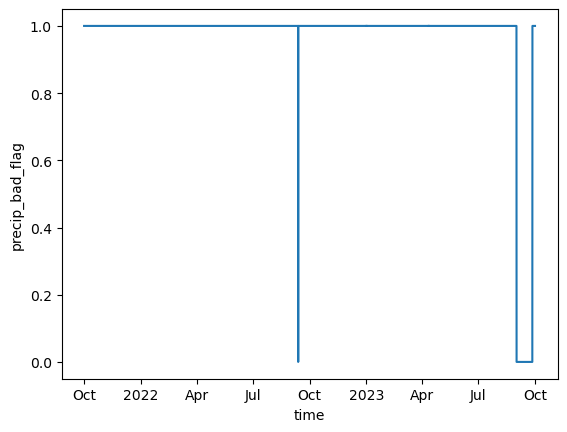

In [6]:
ds = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/billy_barr/billy_barr_20211001-20230930_30min.nc")
ds['precip_bad_flag'].plot()

In [17]:
df['datetime'] = pd.to_datetime(df['Year'].astype(str) + df['Month'].astype(str) + df['Day'].astype(str), format='%Y%m%d')
df = df.set_index('datetime')
df.drop(columns=['Year', 'Month', 'Day'], inplace=True)

# adjust SWE column to be in cm from in
df['SWE'] = df['SWE'] * 2.54
df['water_total'] = df['water_total'] * 2.54
df['rain'] = df['rain'] * 2.54

ds = df.to_xarray()
ds['T_min'].attrs['units'] = 'degC'
ds['T_min'].attrs['long_name'] = 'Daily Minimum Air Temperature'
ds['T_max'].attrs['units'] = 'degC'
ds['T_max'].attrs['long_name'] = 'Daily Maximum Air Temperature'
ds['snow'].attrs['units'] = 'cm'
ds['snow'].attrs['long_name'] = 'Daily Snowfall'
ds['SWE'].attrs['units'] = 'cm'
ds['SWE'].attrs['long_name'] = 'Daily Snow Water Equivalent'
ds['snow_total'].attrs['units'] = 'cm'
ds['snow_total'].attrs['long_name'] = 'Total Snowfall -- do not use'
ds['water_total'].attrs['units'] = 'cm'
ds['water_total'].attrs['long_name'] = 'Total Water Equivalent on Ground'
ds['snow_depth'].attrs['units'] = 'cm'
ds['snow_depth'].attrs['long_name'] = 'Snow Depth on Ground'
ds['rain'].attrs['units'] = 'cm'
ds['rain'].attrs['long_name'] = 'Daily Rainfall'

In [4]:
def fast_mode_rounded(x):
    arr = x.to_numpy()
    arr = arr[~np.isnan(arr)]  # drop NaNs fast
    if arr.size == 0:
        return np.nan
    rounded = (10 * np.round(arr / 10)).astype(int)
    vals, counts = np.unique(rounded, return_counts=True)
    return vals[np.argmax(counts)]
# remove spaces from all column names
df.columns = df.columns.str.replace(' ', '')

In [ ]:
vars_to_keep = [
    "date","time","windSpeed_m_per_s","flg_windSpeed","windVecMag_m_per_s","flg_windVecMag",
    "windDirec_Deg", "flg_windDirec", "mxAirTemp_Deg_C", "flg_mxAirTemp", "mnAirTemp_Deg_C", "flg_mnAirTemp",
    "avAirTemp_Deg_C", "flg_avAirTemp", "relHumidty_%", "flg_relHumidty", "baromPress_mbar", "flg_baromPress",
    "precip_mm", "flg_precip", 'accumPcpn_mm',  'flg_accumPcpn', 
]
flg_vars = [var for var in vars_to_keep if var.startswith("flg_")]
non_flg_vars = [var for var in vars_to_keep if not var.startswith("flg_")]
non_flg_vars.remove("date")
non_flg_vars.remove("time")

# zip flag and non-flag variables together
for non_flg_var, flg_var in zip(non_flg_vars, flg_vars):
    # set non-flag variable to NaN where flag variable is not 0
    df[non_flg_var] = df[non_flg_var].where(df[flg_var].isin([0,'0','E']), np.nan)

sub_df = df[vars_to_keep]
# make the index the combination of date and time
sub_df.index = pd.to_datetime(sub_df['date'] + ' ' + sub_df['time'])
sub_df = sub_df.drop(columns=['date', 'time'])

# remove spaces from all column names
sub_df.columns = sub_df.columns.str.replace(' ', '')

# replace -9999.9 with NaN in all columns except flag columns
for col in sub_df.columns:
    if col not in flg_vars:
        sub_df[col] = sub_df[col].replace(-9999.0, np.nan)

# drop flag columns
sub_df = sub_df.drop(columns=flg_vars)

# resample to 30 min intervals
sub_df_30min = sub_df.resample('30min').agg(
    {
        'windSpeed_m_per_s': 'mean',
        'windVecMag_m_per_s': 'mean',
        'windDirec_Deg': fast_mode_rounded,
        'mxAirTemp_Deg_C': 'mean',
        'mnAirTemp_Deg_C': 'mean',
        'avAirTemp_Deg_C': 'mean',
        'relHumidty_%': 'mean',
        'baromPress_mbar': 'mean',
        'precip_mm': 'sum',
        'accumPcpn_mm': 'sum',
    }
)

In [8]:
# convert to xarray dataset
ds_30min = sub_df_30min.to_xarray()

# rename index to time
ds_30min = ds_30min.rename({'index': 'time'})

# rename variables by removing units after '_' from name, then save units in attrs
var_rename_dict = {
    'windSpeed_m_per_s': 'windSpeed',
    'windVecMag_m_per_s': 'windVecMag',
    'windDirec_Deg': 'windDirec',
    'mxAirTemp_Deg_C': 'mxAirTemp',
    'mnAirTemp_Deg_C': 'mnAirTemp',
    'avAirTemp_Deg_C': 'avAirTemp',
    'relHumidty_%': 'relHumidty',
    'baromPress_mbar': 'baromPress',
    'precip_mm': 'precip',
    'accumPcpn_mm': 'accumPcpn',
    # 'SnowDepth_mm': 'SnowDepth',
}
for old_name, new_name in var_rename_dict.items():
    ds_30min = ds_30min.rename({old_name: new_name})
    # save units in attrs
    if old_name.endswith('_m_per_s'):
        ds_30min[new_name].attrs['units'] = 'm/s'
    elif old_name.endswith('_Deg'):
        ds_30min[new_name].attrs['units'] = 'degrees'
    elif old_name.endswith('_Deg_C'):
        ds_30min[new_name].attrs['units'] = 'degC'
    elif old_name.endswith('_mbar'):
        ds_30min[new_name].attrs['units'] = 'mbar'
    elif old_name.endswith('_mm'):
        ds_30min[new_name].attrs['units'] = 'mm'
    elif old_name.endswith('_%'):
        ds_30min[new_name].attrs['units'] = '%'

In [9]:
# add lat, lon, alt variables
ds_30min['lat'] = 38.963
ds_30min['lat'].attrs['units'] = 'degrees_north'

ds_30min['lon'] = -106.993
ds_30min['lon'].attrs['units'] = 'degrees_east'

ds_30min['alt'] = 2917.6
ds_30min['alt'].attrs['units'] = 'meters'

# add global attributes
ds_30min.attrs['site_name'] = 'billy_barr'
ds_30min.attrs['location'] = 'East River Valley, Gothic, Colorado, USA'
ds_30min.attrs['data_source'] = 'Data provided by the billy barr meteorological station, data obtained from https://wrcc.dri.edu/cgi-bin/rawMAIN.pl?corbil'
ds_30min.attrs['processing_notes'] = 'Quality control flags were used to remove erroneous data. Data were resampled to 30 minute intervals using mean for continuous ' \
                                        'variables and sum for precipitation variables. Wind direction was resampled using mode after rounding to nearest 10 degrees.'
ds_30min.attrs['date_created'] = pd.Timestamp.now().isoformat()

# Sand Castle 15: Process PRISM data
Goal is to get the PRISM 800-m grid point over Gothic/Kettle Ponds

In [21]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
import sys, os
project_root = "/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo"
if project_root not in sys.path:
    sys.path.append(project_root)
from utils.helper_funcs import convert_to_local_time, get_point_info

# get the lon and lat values for gothic and kettle ponds
example_gothic_ds = xr.open_dataset(f"{data_dir}processed/SAIL/met_30min.nc")
example_kp_ds = xr.open_dataset(f"{data_dir}processed/SPLASH/asfs30_30min.nc")
gothic_point_info = get_point_info(example_gothic_ds)
kettle_ponds_point_info = get_point_info(example_kp_ds)

# check if PRISM files are present
if not os.path.exists(f"{data_dir}external/PRISM/processed/"):
    print("PRISM data directory not found. Download the data before proceeding.")
try:
    files = glob.glob(f"{data_dir}external/PRISM/processed/prism_ppt_us_30s*.nc")
except Exception as e:
    print(f"Error finding PRISM files: {e}")

In [22]:
ds = xr.open_dataset(files[0])

# select the nearest point to gothic
ds_gothic = ds.sel(lon=gothic_point_info['longitude'].values
                    , lat=gothic_point_info['latitude'].values, method='nearest').squeeze()
ds_gothic = ds_gothic.expand_dims(site=['gothic'])
ds_kettle_ponds = ds.sel(lon=kettle_ponds_point_info['longitude'].values
                    , lat=kettle_ponds_point_info['latitude'].values, method='nearest').squeeze()
ds_kettle_ponds = ds_kettle_ponds.expand_dims(site=['kettle_ponds'])

In [58]:
# extract the date from the filenames
for file in files:
    date_str = file.split('_')[-2]
    date = pd.to_datetime(date_str, format='%Y%m%d')
    ds = xr.open_dataset(file)
    # add a time dimension
    ds = ds.expand_dims(time=[date])
    # select the nearest point to gothic
    ds_gothic = ds.sel(lon=gothic_point_info['longitude'].values
                        , lat=gothic_point_info['latitude'].values, method='nearest').squeeze()
    ds_gothic = ds_gothic.expand_dims(site=['gothic'])
    ds_kettle_ponds = ds.sel(lon=kettle_ponds_point_info['longitude'].values
                        , lat=kettle_ponds_point_info['latitude'].values, method='nearest').squeeze()
    ds_kettle_ponds = ds_kettle_ponds.expand_dims(site=['kettle_ponds'])

    # concatenate to single dataset
    ds_sites = xr.concat([ds_gothic, ds_kettle_ponds], dim='site')
    if 'ds_all' in locals():
        ds_all = xr.concat([ds_all, ds_sites], dim='time')
    else:
        ds_all = ds_sites
    

In [ ]:
xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/PRISM/prism_site_data.nc").sel(site='kettle_ponds')['ppt'].plot()

NameError: name 'xr' is not defined

# Sand Castle 16: Process ERA5-Land data
Goal is to get the ERA5-Land 9-km grid point over Gothic/Kettle Ponds

In [83]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
import sys, os
project_root = "/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo"
if project_root not in sys.path:
    sys.path.append(project_root)
from utils.helper_funcs import convert_to_local_time, get_point_info

# check if ERA5-Land files are present
if not os.path.exists(f"{data_dir}external/ERA5-Land/"):
    print("ERA5-Land data directory not found. Download the data before proceeding.")
try:
    files = glob.glob(f"{data_dir}external/ERA5-Land/era5_land_20211001_20230930.nc")
except Exception as e:
    print(f"Error finding ERA5-Land file: {e}")

In [ ]:
era5_land_ds = xr.open_dataset(files[0])
# get the lon and lat values for gothic and kettle ponds
example_gothic_ds = xr.open_dataset(f"{data_dir}processed/SAIL/met_30min.nc")
example_kp_ds = xr.open_dataset(f"{data_dir}processed/SPLASH/asfs30_30min.nc")
gothic_point_info = get_point_info(example_gothic_ds)
kettle_ponds_point_info = get_point_info(example_kp_ds)

In [ ]:
era5_land_point = era5_land_ds.sel(longitude=gothic_point_info['longitude'].values, latitude=gothic_point_info['latitude'].values, method='nearest').squeeze()

# change to local time
era5_land_point = convert_to_local_time(era5_land_point, local_tz='America/Denver', time_variable='valid_time')

# convert from m to mm for precipitation variables
era5_land_point['tp'] = era5_land_point['tp'] * 1000
era5_land_point['tp'].attrs['units'] = 'mm'
# add longname
era5_land_point['tp'].attrs['long_name'] = 'Total Precipitation'
# add timezone attribute
era5_land_point.attrs['timezone'] = 'America/Denver (MST/MDT)'

# rename valid_time to time
era5_land_point = era5_land_point.swap_dims({'valid_time': 'time'})

# remove timezone
era5_land_point['time'] = pd.to_datetime(era5_land_point['time'].values).tz_localize(None)

# drop valid_time, number, exper 
era5_land_point = era5_land_point.drop_vars(['valid_time', 'number', 'expver'])

# save to netcdf
output_path = f"{data_dir}/processed/ERA5-Land/era5_land_gothic_1hr.nc"

In [106]:
ds = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data//processed/ERA5-Land/era5_land_gothic_1hr.nc")

# Sand Castle 17: Optical rain gauge

In [2]:
import glob
import os
import sys, os
project_root = "/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo"
if project_root not in sys.path:
    sys.path.append(project_root)
from utils import process_sail_data
from utils.helper_funcs import convert_to_local_time, qc_sail_met, calculate_wind_components
import xarray as xr
import time
import numpy as np
from scipy import stats
import pandas as pd

# Assign data directory and get files
data_dir = "/storage/dlhogan/precipitation-rodeo/data/"
files = glob.glob(f"{data_dir}raw/SAIL/maws/*.nc")

In [6]:
xr.open_dataset("/storage/dlhogan/synoptic_sublimation/sail_data/winter_21_22/met_20211001_20220930.nc")

<xarray.Dataset> Size: 134MB
Dimensions:                       (time: 524933, bound: 2)
Coordinates:
  * time                          (time) datetime64[ns] 4MB 2021-10-01 ... 20...
Dimensions without coordinates: bound
Data variables: (12/51)
    base_time                     (time) datetime64[ns] 4MB ...
    time_offset                   (time) datetime64[ns] 4MB ...
    time_bounds                   (time, bound) datetime64[ns] 8MB ...
    atmos_pressure                (time) float32 2MB ...
    qc_atmos_pressure             (time) int32 2MB ...
    temp_mean                     (time) float32 2MB ...
    ...                            ...
    qc_logger_volt                (time) int32 2MB ...
    logger_temp                   (time) float32 2MB ...
    qc_logger_temp                (time) int32 2MB ...
    lat                           (time) float32 2MB ...
    lon                           (time) float32 2MB ...
    alt                           (time) float32 2MB ...
Attributes: (12/21)
    command_line:                met_ingest -s guc -f M1 -RD --max-runtime 0
    Conventions:                 ARM-1.3
    process_version:             ingest-met-4.53-0.el7
    dod_version:                 met-b1-11.2
    input_source:                /data/reproc/D221103.2/collection/guc/gucmet...
    site_id:                     guc
    ...                          ...
    averaging_interval_comment:  The time assigned to each data point indicat...
    org:                         Optical Rain Gauge
    tbrg:                        Tipping Bucket Rain Gauge
    pwd:                         Present Weather Detector
    tbrg_precip_corr_info:       0.000000 * tbrg_precip_total^2 + 0.000000 * ...
    history:                     created by user yahmad on machine prod-proc5...

# Sand Castle 18: Process SPLASH Laser Disdrometer

In [2]:
import numpy as np
import os
import pandas as pd
import xarray as xr
import glob
os.chdir("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/")

original_storage_path = '/storage/dlhogan/precipitation-rodeo/data/raw/SPLASH/'
final_storage_path = '/storage/dlhogan/precipitation-rodeo/data/processed/SPLASH/'
if not os.path.exists(original_storage_path+'laser_disdrometer_raw_KP'):
    print("Download data using ~/01a_data_access/splash/laser_disdrometer_raw_data_download.py")
else:
    print('Data already downloaded')
    # we'll start by loading in one file and looking at the data
    original_storage_path = '/storage/dlhogan/precipitation-rodeo/data/raw/SPLASH/laser_disdrometer_raw_KP/*'
    raw_files = glob.glob(original_storage_path)

Data already downloaded


In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import xarray as xr
import glob
import os
from datetime import datetime
from utils.helper_funcs import convert_to_local_time

# -------------------------------------------------------
# Bin coordinate definitions
# -------------------------------------------------------
size_bins = np.array([
    0.062,0.187,0.312,0.437,0.562,0.687,0.812,0.937,
    1.062,1.187,1.375,1.625,1.875,2.125,2.375,2.750,
    3.250,3.750,4.250,4.750,5.500,6.500,7.500,8.500,
    9.500,11.000,13.000,15.000,17.000,19.000,21.500,24.500
])

velocity_bins = np.array([
    0.05,0.15,0.25,0.35,0.45,0.55,0.65,0.75,
    0.85,0.95,1.10,1.30,1.50,1.70,1.90,2.20,
    2.60,3.00,3.40,3.80,4.40,5.80,6.00,6.80,
    7.60,8.80,10.40,12.00,13.60,15.20,17.60,20.80
])

# filepath = raw_files[100]
def process_raw_laser_disdrometer_file(filepath):
    # -------------------------------------------------------
    # 1. Read header (date + hour)
    # -------------------------------------------------------
    with open(filepath, "r") as f:
        header = f.readline().strip()

    date_str = header.split()[0]        # "09/30/2021"
    time_str = header.split()[1]        # "21:00"

    file_date = datetime.strptime(date_str, "%m/%d/%Y").date()
    file_hour = int(time_str.split(":")[0])  # 21

    # -------------------------------------------------------
    # 2. Prepare lists
    # -------------------------------------------------------
    times = []
    precip_intensity = []
    accum_precip = []
    reflectivity = []
    particle_count_tot = []
    sensor_status = []
    error_code = []

    Nd_list = []
    vd_list = []
    PSD_list = []

    # -------------------------------------------------------
    # 3. Line-by-line parsing
    # -------------------------------------------------------
    with open(filepath, "r") as f:
        lines = f.readlines()[1:]   # skip header

    for line in lines:
        parts = line.strip().split()

        # Whitespace-delimited fields 1–7
        timestamp_raw = parts[0]
        precip_intensity.append(float(parts[1]))
        accum_precip.append(float(parts[2]))
        reflectivity.append(float(parts[3]))
        particle_count_tot.append(int(parts[4]))
        sensor_status.append(int(parts[5]))
        error_code.append(int(parts[6]))

        # Time parsing
        MMSSmmm = timestamp_raw.zfill(7)
        minute = int(MMSSmmm[0:2])
        second = int(MMSSmmm[2:4])

        times.append(
            datetime(file_date.year, file_date.month, file_date.day,
                    file_hour, minute, second)
        )

        # Everything after the first 7 fields:
        rest = " ".join(parts[7:])

        # Split *only* on commas → yields Nd + vd + PSD values
        vals = rest.replace(" ", ",").split(",")

        # Convert to floats, treating missing as NaN
        missing_vals = {"", "-9999", "-9", "-9.9", "-9.99", "-9.999"}

        vals = [float(v) if v not in missing_vals else np.nan for v in vals]

        # Required: 32 + 32 + 1024 = 1088 values
        if len(vals) != 1088:
            # Sometimes trailing commas produce 1089; trim
            vals = vals[:1088]

        # Extract Nd, vd, PSD
        Nd = np.array(vals[0:32])
        vd = np.array(vals[32:64])
        PSD_flat = np.array(vals[64:1088])      # 1024 values
        PSD = PSD_flat.reshape(32, 32)          # (velocity, size)

        Nd_list.append(Nd)
        vd_list.append(vd)
        PSD_list.append(PSD)

    # Stack arrays
    Nd_arr = np.stack(Nd_list)
    vd_arr = np.stack(vd_list)
    PSD_arr = np.stack(PSD_list)   # (time, velocity, size)
    
    class_size_width = np.array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.25 , 0.25 , 0.25 , 0.25 , 0.25 , 0.5  , 0.5  , 0.5  ,
       0.5  , 0.5  , 1.   , 1.   , 1.   , 1.   , 1.   , 2.   , 2.   ,
       2.   , 2.   , 2.   , 3.   , 3.   ])
    class_size_width = np.tile(class_size_width, (len(times), 1))

    # -------------------------------------------------------
    # 5. Build dataset
    # -------------------------------------------------------
    ds = xr.Dataset(
        data_vars={
            "precip_intensity":   ("time", np.array(precip_intensity)),
            "accum_precip":       ("time", np.array(accum_precip)),
            "reflectivity":       ("time", np.array(reflectivity)),
            "particle_count_tot": ("time", np.array(particle_count_tot)),
            "sensor_status":      ("time", np.array(sensor_status)),
            "error_code":         ("time", np.array(error_code)),

            "Nd":  (("time", "size_bin"), Nd_arr),
            "vd":  (("time", "velocity_bin"), vd_arr),
            "class_size_width": (("time","size_bin"), class_size_width),
            "PSD": (("time", "velocity_bin", "size_bin"), PSD_arr),
        },

        coords={
            "time": np.array(times),
            "size_bin": size_bins,
            "velocity_bin": velocity_bins,
        }
    )
    ds = ds.where(ds != -9.999)
    return ds


In [4]:
def process_stats_laser_disdrometer_file(filepath, reasonable_threshold=None):
    """
    Process a laser disdrometer file and return a xarray Dataset with the data.
    """
    # Read the file
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    # Parse the header for metadata (assuming first line is header)
    header = lines[0].strip()
    instrument_info, time_info = header.split(" Time (YYJJJHH): ")
    year = int("20" + time_info[:2])
    day_of_year = int(time_info[2:5])
    start_hour = int(time_info[5:7])

    # Skip the first two lines
    lines = lines[2:]
    
    # Initialize a list to store parsed data
    data = []

    # Process each line in the file
    for i, line in enumerate(lines):
        fields = line.strip().split()
        
        # Skip lines that don't have the correct number of fields
        if len(fields) != 57:
            continue
        
        # Extract and convert data fields
        begin_time_str = fields[0].split('-')[0]
        end_time_str = fields[0].split('-')[1]
        particle_distribution = list(map(int, fields[1:33]))
        qc_data = list(map(int, fields[33:36]))
        precip_stats = list(map(float, fields[36:41]))
        laser_status = list(map(float, fields[41:47]))
        sensor_status = list(map(float, fields[47:53]))
        precip_partitioning = list(map(int, fields[53:57]))

        # Convert begin_time and end_time to timestamps
        begin_time = pd.Timestamp(year, 1, 1) + pd.Timedelta(days=day_of_year-1, hours=start_hour,
                                                                minutes=int(begin_time_str[0:2]), 
                                                                seconds=int(begin_time_str[3:5]),
                                                                milliseconds=int(begin_time_str[6:9]))
        end_time = pd.Timestamp(year, 1, 1) + pd.Timedelta(days=day_of_year-1, hours=start_hour,
                                                                minutes=int(end_time_str[0:2]), 
                                                                seconds=int(end_time_str[3:5]), 
                                                                milliseconds=int(end_time_str[6:9]))
        # If end time is before begin time, increment the hour by 1
        if end_time < begin_time:
            end_time += pd.Timedelta(hours=1)
        
        data.append({
            "time": begin_time,
            "particle_distribution": particle_distribution,
            "qc_data": qc_data,
            "precip_stats": precip_stats,
            "laser_status": laser_status,
            "sensor_status": sensor_status,
            "precip_partitioning": precip_partitioning
        })
    
    # Create a DataFrame from the data
    df = pd.DataFrame(data)

    # Ensure all lists in df have consistent lengths
    assert all(len(item) == 32 for item in df["particle_distribution"]), "Mismatch in particle_distribution length"
    assert all(len(item) == 3 for item in df["qc_data"]), "Mismatch in qc_data length"
    assert all(len(item) == 5 for item in df["precip_stats"]), "Mismatch in precip_stats length"
    assert all(len(item) == 6 for item in df["laser_status"]), "Mismatch in laser_status length"
    assert all(len(item) == 6 for item in df["sensor_status"]), "Mismatch in sensor_status length"
    assert all(len(item) == 4 for item in df["precip_partitioning"]), "Mismatch in precip_partitioning length"

    # Convert DataFrame to xarray Dataset
    ds = xr.Dataset(
        {
            "particle_distribution": (("time", "size_bin"), np.stack(df["particle_distribution"].values)),
            "Blackout": ("time", df["qc_data"].apply(lambda x: x[0])),
            "Good": ("time", df["qc_data"].apply(lambda x: x[1])),
            "Bad": ("time", df["qc_data"].apply(lambda x: x[2])),
            "NumParticle": ("time", df["precip_stats"].apply(lambda x: x[0])),
            "Rate": ("time", df["precip_stats"].apply(lambda x: x[1]), {"units": "mm/h", "descriptor": "Precipitation"}),
            "Amount": ("time", df["precip_stats"].apply(lambda x: x[2]), {"units": "mm", "descriptor": "Precipitation"}),
            "AmountSum": ("time", df["precip_stats"].apply(lambda x: x[3]), {"units": "mm", "descriptor": "Precipitation"}),
            "Z": ("time", df["precip_stats"].apply(lambda x: x[4]), {"units": "dB", "descriptor": "Precipitation"}),
            "NumError": ("time", df["laser_status"].apply(lambda x: x[0])),
            "Dirty": ("time", df["laser_status"].apply(lambda x: x[1])),
            "VeryDirty": ("time", df["laser_status"].apply(lambda x: x[2])),
            "Damaged": ("time", df["laser_status"].apply(lambda x: x[3])),
            "SignalAvg": ("time", df["laser_status"].apply(lambda x: x[4])),
            "SignalStdDev": ("time", df["laser_status"].apply(lambda x: x[5])),
            "TempAvg": ("time", df["sensor_status"].apply(lambda x: x[0]), {"units": "C", "descriptor": "Sensor Status"}),
            "TempStdDev": ("time", df["sensor_status"].apply(lambda x: x[1]), {"units": "C", "descriptor": "Sensor Status"}),
            "VoltAvg": ("time", df["sensor_status"].apply(lambda x: x[2]), {"units": "V", "descriptor": "Sensor Status"}),
            "VoltStdDev": ("time", df["sensor_status"].apply(lambda x: x[3]), {"units": "V", "descriptor": "Sensor Status"}),
            "HeatCurrentAvg": ("time", df["sensor_status"].apply(lambda x: x[4]), {"units": "A", "descriptor": "Sensor Status"}),
            "HeatCurrentStdDev": ("time", df["sensor_status"].apply(lambda x: x[5]), {"units": "A", "descriptor": "Sensor Status"}),
            "NumRain": ("time", df["precip_partitioning"].apply(lambda x: x[0])),
            "NumNoRain": ("time", df["precip_partitioning"].apply(lambda x: x[1])),
            "NumAmbig": ("time", df["precip_partitioning"].apply(lambda x: x[2])),
            "Type": ("time", df["precip_partitioning"].apply(lambda x: x[3]))
        },
        coords={
            "time": df["time"].values,
            "size_bin": size_bins,
        }
    )
    
    # apply reasonableness threshold
    if reasonable_threshold is not None:
        ds['Amount'] = ds['Amount'].where(ds['Amount'] <= reasonable_threshold, np.nan)
    
    # Add descriptor attributes
    ds["Blackout"].attrs["descriptor"] = "Samples"
    ds["Good"].attrs["descriptor"] = "Samples"
    ds["Bad"].attrs["descriptor"] = "Samples"
    ds["NumParticle"].attrs["descriptor"] = "Precipitation"
    ds["NumParticle"].attrs["units"] = ""
    ds["Rate"].attrs["descriptor"] = "Precipitation"
    ds["Amount"].attrs["descriptor"] = "Precipitation"
    ds["AmountSum"].attrs["descriptor"] = "Precipitation"
    ds["Z"].attrs["descriptor"] = "Precipitation"
    ds["NumError"].attrs["descriptor"] = "Laser Status"
    ds["Dirty"].attrs["descriptor"] = "Laser Status"
    ds["VeryDirty"].attrs["descriptor"] = "Laser Status"
    ds["Damaged"].attrs["descriptor"] = "Laser Status"
    ds["SignalAvg"].attrs["descriptor"] = "Laser Status"
    ds["SignalStdDev"].attrs["descriptor"] = "Laser Status"
    ds["TempAvg"].attrs["descriptor"] = "Sensor Status"
    ds["TempStdDev"].attrs["descriptor"] = "Sensor Status"
    ds["VoltAvg"].attrs["descriptor"] = "Sensor Status"
    ds["VoltStdDev"].attrs["descriptor"] = "Sensor Status"
    ds["HeatCurrentAvg"].attrs["descriptor"] = "Sensor Status"
    ds["HeatCurrentStdDev"].attrs["descriptor"] = "Sensor Status"
    ds["NumRain"].attrs["descriptor"] = "Precipitation Partitioning"
    ds["NumNoRain"].attrs["descriptor"] = "Precipitation Partitioning"
    ds["NumAmbig"].attrs["descriptor"] = "Precipitation Partitioning"
    ds["Type"].attrs["descriptor"] = "Precipitation Partitioning"


        # Particle distribution
    ds["particle_distribution"].attrs["long_name"] = "Partical distribution (count) binned by ClassNumber"

    # Data acquisition software quality control
    ds["Blackout"].attrs["long_name"] = "number of data samples excluded during PC clock synchronization"
    ds["Good"].attrs["long_name"] = "number of samples that passed the quality control checks, as performed by the data acquisition software"
    ds["Bad"].attrs["long_name"] = "number of samples that failed the quality control checks, as performed by the data acquisition software"

    # Precipitation statistics
    ds["NumParticle"].attrs["long_name"] = "total number of detected particles"
    ds["Rate"].attrs["long_name"] = "rain rate"
    ds["Amount"].attrs["long_name"] = "interval rain accumulation"
    ds["AmountSum"].attrs["long_name"] = "event rain accumulation"
    ds["Z"].attrs["long_name"] = "radar reflectivity factor"

    # Laser status
    ds["NumError"].attrs["long_name"] = "number of sample instances that were reported as dirty, very dirty, or damaged"
    ds["Dirty"].attrs["long_name"] = "laser protective glass is dirty, but measurements are still possible"
    ds["VeryDirty"].attrs["long_name"] = "laser protective glass is dirty, partially covered; no further usable measurements are possible"
    ds["Damaged"].attrs["long_name"] = "laser damaged"
    ds["SignalAvg"].attrs["long_name"] = "average signal amplitude of the laser strip"
    ds["SignalStdDev"].attrs["long_name"] = "standard deviation of the signal amplitude of the laser strip"

    # Sensor status
    ds["TempAvg"].attrs["long_name"] = "average sensor temperature"
    ds["TempStdDev"].attrs["long_name"] = "standard deviation of the sensor temperature"
    ds["VoltAvg"].attrs["long_name"] = "sensor power supply voltage"
    ds["VoltStdDev"].attrs["long_name"] = "standard deviation of the sensor power supply voltage"
    ds["HeatCurrentAvg"].attrs["long_name"] = "average heating system current"
    ds["HeatCurrentStdDev"].attrs["long_name"] = "standard deviation of the heating system current"

    # Precipitation partitioning
    ds["NumRain"].attrs["long_name"] = "number of particles detected as rain"
    ds["NumNoRain"].attrs["long_name"] = "number of particles detected not as rain"
    ds["NumAmbig"].attrs["long_name"] = "number of particles detected as ambiguous"
    ds["Type"].attrs["long_name"] = "precipitation type (1=rain; 2=mixed; 3=snow)"

    ds['time'].attrs['long_name'] = 'Time (UTC)'

    return ds


In [5]:

# -------------------------------------------------------
# 4. Snowfall rate correction function
# -------------------------------------------------------
parsivel_correction_dict = { 
    'holroyd1971': [0.17, -1],
    'brandes2007': [0.178, -0.922],
    'heymsfield2004': [0.104, -0.95],
    'huang2010' : [0.115, -1.188]
}
def correct_SPLASH_parsivel_for_snow(ds, method='holroyd1971'):
    """
    Correct snowfall rate using a method discussed in Boudala et al. 2014
    """
    a = parsivel_correction_dict[method][0]
    b = parsivel_correction_dict[method][1]
    # Number density of particles
    N_D = ds['Nd']
    # Fall velocity of particles summed over velocity_bin
    V_D = ds['vd']
    # Class size width
    class_size_width = ds['class_size_width']

    # Apply the condition to include particle sizes from 3 to 31
    size_bin_indices = range(3, 32)
    velocity_bin_indices = range(3, 32)

    # Select the relevant slices using isel
    N_D_masked = N_D.isel(size_bin=size_bin_indices)
    class_size_width_masked = class_size_width.isel(size_bin=size_bin_indices)
    V_D_masked = V_D.isel(velocity_bin=velocity_bin_indices)

    # Calculate the snowfall rate using vectorized operations
    result = (N_D_masked * V_D_masked * class_size_width_masked ** (3 + b)).sum(dim='size_bin').sum(dim='velocity_bin')

    # Calculate the final result
    final_result = (6 * a * np.pi * 10e-4 * result)
    return final_result


In [ ]:
def resample_raw_laser_disdrometer_data(file, resample_interval='30min', local_tz='America/Denver'):
    raw_ds = process_raw_laser_disdrometer_file(file,)
    raw_ds = convert_to_local_time(raw_ds, local_tz=local_tz)

    # Resample everything using the controlled method:
    precip_rate_unadjusted = raw_ds['precip_intensity']
    precip_rate_holyroyd    = correct_SPLASH_parsivel_for_snow(raw_ds, method='holroyd1971')
    precip_rate_brandes     = correct_SPLASH_parsivel_for_snow(raw_ds, method='brandes2007')
    precip_rate_heymsfield  = correct_SPLASH_parsivel_for_snow(raw_ds, method='heymsfield2004')
    
    # name variables
    precip_rate_unadjusted.name = 'precip_rate_unadjusted'
    precip_rate_holyroyd.name = 'precip_rate_holyroyd'
    precip_rate_brandes.name = 'precip_rate_brandes'
    precip_rate_heymsfield.name = 'precip_rate_heymsfield'

    # add unit and long_name attributes
    for precip_rate, method in zip([precip_rate_holyroyd, precip_rate_brandes, precip_rate_heymsfield],
                                ['holroyd1971', 'brandes2007', 'heymsfield2004']):
        precip_rate.attrs['units'] = 'mm/hr'
        precip_rate.attrs['long_name'] = f'Precipitation rate corrected for snow using {method} method'

    # 5. create accumulated variable
    precip_accum_unadjusted = precip_rate_unadjusted/30 # convert from mm/hr to mm/min
    precip_accum_holyroyd = precip_rate_holyroyd/30
    precip_accum_brandes = precip_rate_brandes/30
    precip_accum_heymsfield = precip_rate_heymsfield/30

    # toss values less than 0.01
    precip_accum_unadjusted = precip_accum_unadjusted.where(precip_accum_unadjusted >= 0.001, 0)
    precip_accum_holyroyd = precip_accum_holyroyd.where(precip_accum_holyroyd >= 0.001, 0)
    precip_accum_brandes = precip_accum_brandes.where(precip_accum_brandes >= 0.001, 0)
    precip_accum_heymsfield = precip_accum_heymsfield.where(precip_accum_heymsfield >= 0.001, 0)

    precip_accum_unadjusted.name = 'precip_accum_unadjusted'
    precip_accum_holyroyd.name = 'precip_accum_holyroyd'
    precip_accum_brandes.name = 'precip_accum_brandes'
    precip_accum_heymsfield.name = 'precip_accum_heymsfield'

    precip_accum_unadjusted.attrs['units'] = 'mm'
    precip_accum_holyroyd.attrs['units'] = 'mm'

    precip_accum_brandes.attrs['units'] = 'mm'
    precip_accum_heymsfield.attrs['units'] = 'mm'

    precip_accum_unadjusted.attrs['long_name'] = 'Accumulated precipitation unadjusted'
    precip_accum_holyroyd.attrs['long_name'] = 'Accumulated precipitation corrected using holroyd1971 method'
    precip_accum_brandes.attrs['long_name'] = 'Accumulated precipitation corrected using brandes2007 method'
    precip_accum_heymsfield.attrs['long_name'] = 'Accumulated precipitation corrected using heymsfield2004 method'

    # accumulated variables: sum
    precip_accum_unadjusted_da = precip_accum_unadjusted.resample(time=resample_interval).sum()
    precip_accum_holyroyd_da = precip_accum_holyroyd.resample(time=resample_interval).sum()
    precip_accum_brandes_da = precip_accum_brandes.resample(time=resample_interval).sum()
    precip_accum_heymsfield_da = precip_accum_heymsfield.resample(time=resample_interval).sum()
   
    # mean variables: 
    precip_rate_unadjusted_da = precip_rate_unadjusted.resample(time=resample_interval).mean()
    precip_rate_holyroyd_da = precip_rate_holyroyd.resample(time=resample_interval).mean()
    precip_rate_brandes_da = precip_rate_brandes.resample(time=resample_interval).mean()
    precip_rate_heymsfield_da = precip_rate_heymsfield.resample(time=resample_interval).mean()

    raw_ds_resampled = xr.merge([
        precip_accum_unadjusted_da,
        precip_accum_brandes_da,
        precip_accum_heymsfield_da,
        precip_accum_holyroyd_da,
        precip_rate_holyroyd_da,
        precip_rate_unadjusted_da,
        precip_rate_brandes_da,
        precip_rate_heymsfield_da,
    ])
    return raw_ds_resampled

def resample_stats_laser_disdrometer_data(stats_file, resample_interval='30min', local_tz='America/Denver', reasonable_threshold=None):
    
    stats_ds = process_stats_laser_disdrometer_file(stats_file, reasonable_threshold=reasonable_threshold)
    stats_ds = convert_to_local_time(stats_ds, local_tz=local_tz)    
    # create qc_bad_precip variable
    stats_ds['qc_bad_precip'] = ((stats_ds['Bad'] != 0) |
                           (stats_ds['Damaged'] != 0)).astype(int).astype(bool)
    # create qc_missing_precip variable
    stats_ds['qc_missing_precip'] = stats_ds['Amount'].isnull().astype(bool)

    # 6. resample to desired length using appropriate function for each variable

    # # flag variables: if greater than 25% of data in interval is missing/bad, flag as True
    n_counts = stats_ds['Amount'].resample(time=resample_interval).count()
    qc_missing_precip_da = ((stats_ds['qc_missing_precip'].resample(time=resample_interval).sum() / n_counts) > 0.25).astype(bool)
    qc_bad_precip_da = ((stats_ds['qc_bad_precip'].resample(time=resample_interval).sum() / n_counts) > 0.25).astype(bool)
    # add name
    qc_missing_precip_da.name = 'qc_missing_precip'
    qc_bad_precip_da.name = 'qc_bad_precip'
    # add flag attributes
    qc_missing_precip_da.attrs['description'] = 'Quality flag for precipitation data: True = missing data, False = data present'
    qc_bad_precip_da.attrs['description'] = 'Quality flag for precipitation data: True = bad data, False = good data'

    # accumulated variables: sum
    precip_accum_stats_da = stats_ds['Amount'].resample(time=resample_interval).sum()
    precip_rate_stats_da = stats_ds['Rate'].resample(time=resample_interval).mean()
    
    # Type variables: mode
    precip_type_da = stats_ds['Type'].resample(time=resample_interval).mean()
    precip_type_da = precip_type_da.where((precip_type_da > 2) | (precip_type_da < 0.5), 1)
    precip_type_da = precip_type_da.where((precip_type_da < 2), 3)
    precip_type_da = precip_type_da.where((precip_type_da > 0.5), np.nan)

    precip_type_da.name = 'precip_type'
    precip_type_da.attrs['description'] = 'Precipitation type (1=rain; 2=mixed; 3=snow)'

    stats_ds_resampled = xr.merge([
        precip_accum_stats_da,
        precip_rate_stats_da,
        precip_type_da,
        qc_missing_precip_da,
        qc_bad_precip_da
    ])
    return stats_ds_resampled


In [13]:
stats_files = glob.glob('/storage/dlhogan/precipitation-rodeo/data/raw/SPLASH/laser_disdrometer_stats_KP/*')

all_raw_datasets = []
for raw_file in raw_files[0:50]:
    try:
        ds = resample_raw_laser_disdrometer_data(raw_file, resample_interval='30min', local_tz='America/Denver')
        all_raw_datasets.append(ds)
    except Exception as e:
        print(f"Error processing {raw_file}: {e}")
        continue
raw_ds = xr.concat(all_raw_datasets, dim='time')

In [14]:
all_stats_datasets = []
for stats_file in stats_files[0:50]:
    try:
        ds = resample_stats_laser_disdrometer_data(stats_file, resample_interval='30min', local_tz='America/Denver', reasonable_threshold=0.522*25.44)
        all_stats_datasets.append(ds)
    except Exception as e:
        print(f"Error processing {stats_files}: {e}")
        continue
stats_ds = xr.concat(all_stats_datasets, dim='time')

In [42]:
ds = xr.merge([stats_ds, raw_ds], join='left')

In [1]:
import xarray as xr
import pandas as pd
ds = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/SPLASH/SPLASH_kp_laser_disdrometer.nc")
# # flag any data that is negative
# tmin = pd.Timestamp(ds.time.min().item()).floor('30min')
# tmax = pd.Timestamp(ds.time.max().item()).ceil('30min')
# full_time_index = pd.date_range(tmin, tmax, freq='30min')
# # drop duplicate times
# ds = ds.sel(time=~ds.get_index('time').duplicated())
# # reindex to full time range
# ds = ds.reindex(time=full_time_index)
# print("Reindexed combined dataset to full time range.")


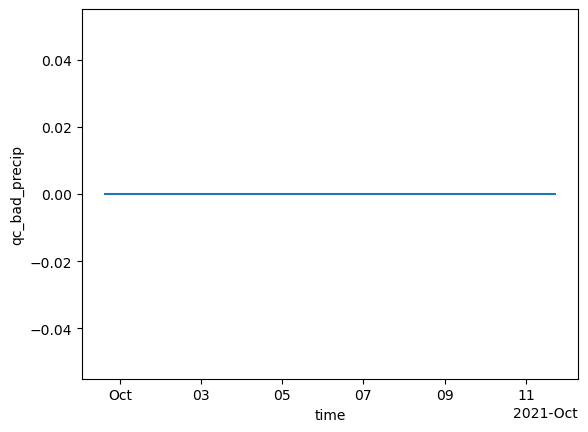

In [2]:
#ds['Amount'].where((ds['qc_bad_precip'] == 1) & (ds['qc_missing_precip']==0)).cumsum().plot()
ds['qc_bad_precip'].plot()

# Sand Castle 19: Normalize met data

In [205]:
import glob
import os
import sys, os
project_root = "/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo"
if project_root not in sys.path:
    sys.path.append(project_root)
from sklearn.preprocessing import StandardScaler
import pandas as pd
from utils.helper_funcs import calculate_wind_components
import numpy as np
from scipy.stats import circmean, circstd, linregress

In [ ]:
billyBarrLongTermMet_ds = xr.open_dataset(f"{data_dir}/processed/billy_barr/billy_barr_20011001-20251025_30min.nc")
kettlePondsAsfs30_ds = xr.open_dataset(f"{data_dir}/processed/SPLASH/asfs30_30min.nc")
kettlePondsSOS_ds = xr.open_dataset(f"{data_dir}/processed/SOS/sos_ds_30min.nc")
gothicMet_ds = xr.open_dataset(f"{data_dir}/processed/SAIL/met_30min.nc")
gothicBB_ds = xr.open_dataset(f"{data_dir}/processed/billy_barr/billy_barr_20211001-20230930_30min.nc")

In [268]:
# first separate wind speed and direction into u and v components
u, v = calculate_wind_components(
    billyBarrLongTermMet_ds['windSpeed'],
    billyBarrLongTermMet_ds['windDirec']
)
billyBarrLongTermMet_ds['u_wind'] = (('time',), u)
billyBarrLongTermMet_ds['v_wind'] = (('time',), v)

u, v = calculate_wind_components(
    gothicBB_ds['windSpeed'],
    gothicBB_ds['windDirec']
)
gothicBB_ds['u_wind'] = (('time',), u)
gothicBB_ds['v_wind'] = (('time',), v)  

In [277]:
VARS =['pressure', 'temperature', 'relative_humidity', 'u_wind', 'v_wind']

# normalize the variable names
kettlePondsAsfs30_ds = kettlePondsAsfs30_ds.rename({
    'atmos_pressure': 'pressure',
    'temp': 'temperature',
    'rh': 'relative_humidity',
    'wspd_u_mean': 'u_wind',
    'wspd_v_mean': 'v_wind',
})
kettlePondsSOS_ds = kettlePondsSOS_ds.rename({
    'P_10m_c': 'pressure',
    'T_3m_c': 'temperature',
    'RH_3m_c': 'relative_humidity',
    'u_10m_c': 'u_wind',
    'v_10m_c': 'v_wind',
})
gothicMet_ds = gothicMet_ds.rename({
    'atmos_pressure': 'pressure',
    'temp_mean': 'temperature',
    'rh_mean': 'relative_humidity',
    'wspd_vec_mean': 'wind_speed',
    'u': 'u_wind',
    'v': 'v_wind',
})
gothicBB_ds = gothicBB_ds.rename({
    'baromPress': 'pressure',
    'avAirTemp': 'temperature',
    'relHumidty': 'relative_humidity',
    'u_wind': 'u_wind',
    'v_wind': 'v_wind',
})
billyBarrLongTermMet_ds = billyBarrLongTermMet_ds.rename({
    'baromPress': 'pressure',
    'avAirTemp': 'temperature',
    'relHumidty': 'relative_humidity',
    'u_wind': 'u_wind',
    'v_wind': 'v_wind',
})

# subset datasets to only these variables
kettlePondsAsfs30_df = kettlePondsAsfs30_ds[VARS].to_dataframe()
kettlePondsSOS_df = kettlePondsSOS_ds[VARS].to_dataframe()
gothicMet_df = gothicMet_ds[VARS].to_dataframe()
gothicBB_df = gothicBB_ds[VARS].to_dataframe()

# long term meteorology
billyBarrLongTermMet_df = billyBarrLongTermMet_ds[VARS].to_dataframe()

In [278]:
# add doy and tod volumns
for df in [kettlePondsAsfs30_df, kettlePondsSOS_df, gothicMet_df, gothicBB_df]:
    df['doy'] = df.index.dayofyear
    df['tod'] = df.index.time
    df['wind_speed'] = np.sqrt(df['u_wind']**2 + df['v_wind']**2)

billyBarrLongTermMet_df['doy'] = billyBarrLongTermMet_df.index.dayofyear

bias_adj_dict = {
    'kettlePondsAsfs30': {
        'u_wind': [1.67, 1],
        'v_wind': [1.22, -0.59],
    },
    'kettlePondsSOS': {
        'u_wind': [1.10, 0],
        'v_wind': [1.62, -0.47],
    },
    'gothicMet': {
        'u_wind': [1.99, 0.78],
        'v_wind': [1.72, -0.62],
    },
    'gothicBB': {
        'u_wind': [1, 0],
        'v_wind': [1, 0],
    },
}

In [279]:
WINDOW_SIZE = 7  # in days, set to None for no smoothing

def standardize_variables(df,bias_adj=None):
    # standardize the variables
    daily_means = df.groupby('doy').mean()
    daily_stds = df.groupby('doy').std()

    if bias_adj:
        for col, (scale, offset) in bias_adj.items():
            print(f"Applying bias adjustment to {col}: scale={scale}, offset={offset}")
            daily_means[col] = (daily_means[col] * scale) + offset
            daily_stds[col] = daily_stds[col] * scale
        daily_means['wind_speed'] = np.sqrt(daily_means['u_wind']**2 + daily_means['v_wind']**2)
        daily_stds['wind_speed'] = np.sqrt(daily_stds['u_wind']**2 + daily_stds['v_wind']**2)
    return daily_means, daily_stds

# subtract the daily climatological means
def anom_df(df, daily_means):
    df_anom = df.copy()
    for var in ['pressure', 'temperature', 'relative_humidity', 'u_wind', 'v_wind', 'wind_speed']:
        df_anom[var] = df_anom[var] - df_anom['doy'].map(daily_means[var])
    return df_anom

def compute_deltaD(df, anom_df, window_size):
    if not window_size:
        deltaD = anom_df.groupby('tod').mean()
    else:
        deltaD_raw = anom_df.groupby(['doy', 'tod']).mean().unstack()
        # add in wind speed climatology
        deltaD = deltaD_raw.rolling(window_size, center=True, min_periods=1).mean()
    # name the index levels to be variable and time of day
    deltaD.columns.set_names(['variable', 'tod'], inplace=True)
    # Stack the DataFrame for easier lookup
    deltaD_stacked = (
        deltaD
        .stack(level=1, future_stack=True)  # stack 'tod'
        .stack(level=0, future_stack=True)  # stack 'var'
    .to_frame('delta_d')
    )
    # create a multiindex from lookup made of day of year and time of day
    lookup_index = pd.MultiIndex.from_arrays(
    [df['doy'], df['tod']],
    names=['doy', 'tod']
    )

    # Broadcast lookup for all variables
    delta_vals = {
        var: deltaD_stacked.xs(var, level='variable').reindex(lookup_index).to_numpy().flatten()
        for var in ['pressure', 'temperature', 'relative_humidity', 'u_wind', 'v_wind', 'wind_speed']
    }

    # Build a DataFrame
    deltaD_df = pd.DataFrame(delta_vals, index=df.index)
    return deltaD_df

def calc_normalized_df(df, deltaD_df, daily_means, daily_stds):
    doy = df['doy']
    mu_daily = pd.DataFrame({v: doy.map(daily_means[v]) for v in deltaD_df.columns})
    sigma_daily = pd.DataFrame({v: doy.map(daily_stds[v]) for v in deltaD_df.columns})

    mu_clim = mu_daily + deltaD_df
    normalized_df = (df[deltaD_df.columns] - mu_clim) / sigma_daily
    return normalized_df

$$\mu_{clim}(t) = \mu_{daily}(d_t) + \Delta_{diurnal}(t,d_t)$$

Normalized value is then
$$X'(t) = \frac{X(t) - \mu_{clim}(t)}{\sigma_{daily}(d_t)}$$

In [280]:
daily_means, daily_stds = standardize_variables(
    billyBarrLongTermMet_df,
    bias_adj=bias_adj_dict['kettlePondsAsfs30']
)
kettlePondsAsfs30_anom_df = anom_df(kettlePondsAsfs30_df, daily_means)
kettlePondsAsfs30_deltaD = compute_deltaD(kettlePondsAsfs30_df, kettlePondsAsfs30_anom_df, WINDOW_SIZE)
kettlePondsAsfs30_normalized = calc_normalized_df(kettlePondsAsfs30_df, kettlePondsAsfs30_deltaD, daily_means, daily_stds)

Applying bias adjustment to u_wind: scale=1.67, offset=1
Applying bias adjustment to v_wind: scale=1.22, offset=-0.59


In [282]:
kettlePondsAsfs30_normalized.to_xarray()

# add units and long_name attributes back
for var in kettlePondsAsfs30_normalized[VARS].columns:
    kettlePondsAsfs30_normalized[var].attrs = kettlePondsAsfs30_ds[var].attrs